In [7]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d


import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
sys.path.append('..')
import plot_settings
import importlib
#import multi_exp_log
import Param_symbol

import GP



from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(plot_settings)
    importlib.reload(Param_symbol)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

# Importing data

In [8]:
RUN_ID = 'first'
SELECTION = 'accuracy'
DT = 1
Q0 = 17921.57581 
ITS = int(20e3)

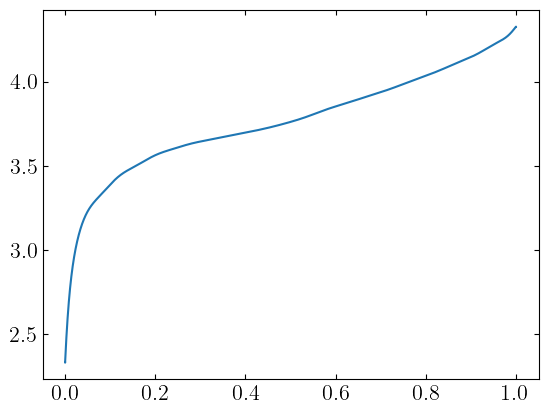

In [9]:
soc = np.linspace(-0.01,1.01,int(1e4))
Ue = GP.soc_to_Ue(soc,GP_FIT) 
plt.plot(soc, Ue)

In [10]:
X_train = soc.reshape(-1,1)
Y_train = Ue.reshape(-1,1)

# $U_{eq} = f_U(\mathrm{SOC})$

Variable names for element Ue: ['soc']
Running symbolic regression for element Ue with run_id R0_first...
Settings: iterations=20000, populations=30, selection=accuracy


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.11742749
Equation: 3.7534175

Model 1: Complexity=3, Loss=0.0184571
Equation: soc + 3.2534037

Model 2: Complexity=4, Loss=0.0154842315
Equation: sqrt(soc) + 3.0900657

Model 3: Complexity=6, Loss=0.005691112
Equation: exp(sqrt(sqrt(soc))) + 1.5074737

Model 4: Complexity=7, Loss=0.0043588285
Equation: sqrt(sqrt(soc) * 3.4456398) + 2.279427

Model 5: Complexity=8, Loss=0.0018361219
Equation: soc + (3.2822444 - exp(soc * -51.673584))

Model 6: Complexity=9, Loss=0.0018361218
Equation: soc + (3.2822444 - square(exp(soc * -25.836792)))

Model 7: Complexity=10, Loss=0.00089526805
Equation: ((soc * 0.8780297) + 3.3491015) - exp(soc * -39.447067)

Model 8: Complexity=11, Loss=0.0005668679
Equation: ((exp(soc) * 0.48762172) - exp(soc * -27.972607)) + 2.9591117

Model 9: Complexity=13, Loss=0.0004869132
Equation: (tan(soc * 0.7210156) - exp(soc * -33.2829)) + 3.395016

Model 10: Complexity=14, Loss=0.00019059551
Equation: ((soc * -8.323827) + (sqrt(soc) * ((soc * 

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (1.1255637*soc + sin((soc*(62.18321 - (1.0112095*soc - (1.0363415 - soc)**3)**36) + 0.02959387)**(1/4)))**2 + 2.1663196
Loss: 4.584203e-05
Best model complexity: 30


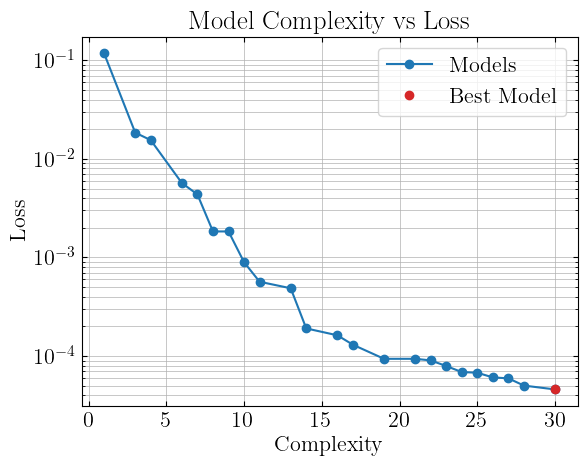

<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in power
  return (1.1255637*soc + sin((soc*(62.18321 - (1.0112095*soc - (1.0363415 - soc)**3)**36) + 0.02959387)**(1/4)))**2 + 2.1663196


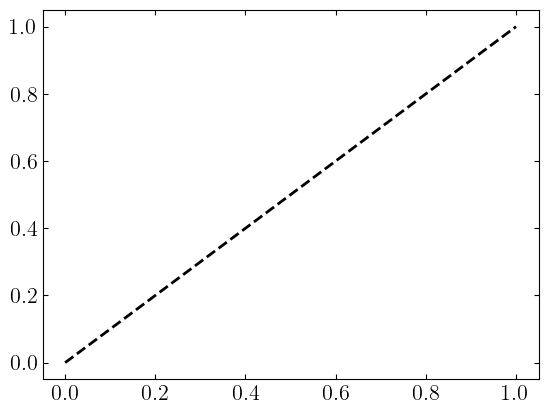

In [11]:
import_reload()
model_Ue = Param_symbol.run_symbolic_regression(X_train, Y_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'Ue')
df_model_Ue = model_Ue.equations_
Param_symbol.print_models(df_model_Ue)
Param_symbol.print_best_model(model_Ue)
Param_symbol.pareto_plot(model_Ue)
Param_symbol.parity_plot_Ue(model_Ue, X_train, Y_train, colors=colors, data_set='train')

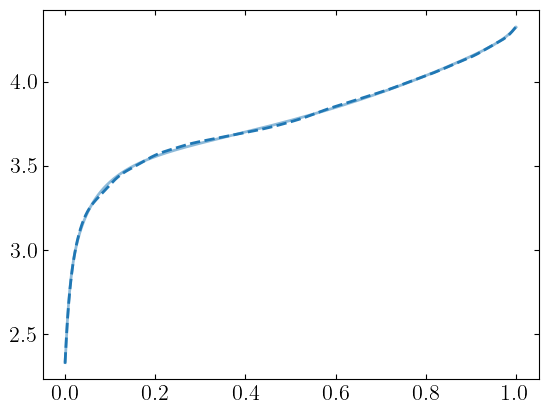

In [12]:
plt.plot(soc, model_Ue.predict(X_train), color=colors[0], alpha = 0.5, label = 'SR fit', lw = 2)
plt.plot(soc, Ue, color = colors[0],ls = '--', lw = 2, label = 'GP fit')

In [13]:
SAVE  = True
if SAVE:
    Param_symbol.save_expressions(df_model_Ue,  f'Ue_{RUN_ID}')
    Param_symbol.save_expressions(model_Ue.get_best(), f'Ue_best_{RUN_ID}')
    
    #save_expressions(df_model_R1, f'R1_{RUN_ID}')
    #save_expressions(df_model_C1, f'C1_{RUN_ID}')